In [4]:
%load_ext autoreload
%autoreload 2

from load_mergetrees import load_mergetree_dir
from compute_edit_distances import compute_distance_matrix

paths = [f"/home/santripta/data_2/tvcg_multiseed_strees_loss/resnet_mnist_{s}/trainUval" for s in ["a", "b", "c"]]

trees = [load_mergetree_dir(path, pattern=".*e144.*", simpl=1e-6) for path in paths]

trees_a = load_mergetree_dir(paths[0], pattern=".*e128.*", simpl=1e-6)
trees_b = load_mergetree_dir(paths[1], pattern=".*e144.*", simpl=1e-6)
trees_c = load_mergetree_dir(paths[2], pattern=".*e136.*", simpl=1e-6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
738 737
finished reading data
init
going over order queue
init
going over order queue
1830 1829
finished reading data
init
going over order queue
init
going over order queue
2194 2193
finished reading data
init
going over order queue
init
going over order queue
2272 2271
finished reading data
init
going over order queue
init
going over order queue
2486 2485
finished reading data
init
going over order queue
init
going over order queue
696 695
finished reading data
init
going over order queue
init
going over order queue
1819 1818
finished reading data
init
going over order queue
init
going over order queue
2111 2110
finished reading data
init
going over order queue
init
going over order queue
2257 2256
finished reading data
init
going over order queue
init
going over order queue
2377 2376
finished reading data
init
going over order queue
init
going over order queue
729 728
finished reading data
init
g

{'ctree_a1_e128_20': <networkx.classes.graph.Graph at 0x7f7b714b1160>,
 'ctree_a2_e128_20': <networkx.classes.graph.Graph at 0x7f7b714b14e0>,
 'ctree_a3_e128_20': <networkx.classes.graph.Graph at 0x7f7b714b1400>,
 'ctree_a4_e128_20': <networkx.classes.graph.Graph at 0x7f7b714b15c0>,
 'ctree_a5_e128_20': <networkx.classes.graph.Graph at 0x7f7b714b16a0>}

In [8]:
layers = ["a1", "a2", "a3", "a4", "a5"]

trees = {
    l: {(k + "_a"): v for k, v in trees_a.items() if l in k} |
       {(k + "_b"): v for k, v in trees_b.items() if l in k} |
       {(k + "_c"): v for k, v in trees_c.items() if l in k}
    for l in layers
}

In [9]:
mat_branch = {}
ord_branch = {}

for l, treedict in trees.items():
    mat_branch[l], ord_branch[l] = compute_distance_matrix(treedict, n_workers=12)

Preparing 3 trees (branch decomposition)…
  3/3 pairs done
Preparing 3 trees (branch decomposition)…


KeyboardInterrupt: 

In [ ]:
mat_path = {}
ord_path = {}

for l, treedict in trees.items():
    mat_path[l], ord_path[l] = compute_distance_matrix(treedict, n_workers=12, method="path")

Preparing 9 trees (branch decomposition)…


RecursionError: maximum recursion depth exceeded

In [10]:
mat_cons = {}
ord_cons = {}

for l, treedict in trees.items():
    mat_cons[l], ord_cons[l] = compute_distance_matrix(treedict, n_workers=12, method="constrained")

Preparing 3 trees (branch decomposition)…
  3/3 pairs done
Preparing 3 trees (branch decomposition)…
  3/3 pairs done
Preparing 3 trees (branch decomposition)…
  3/3 pairs done
Preparing 3 trees (branch decomposition)…
  3/3 pairs done
Preparing 3 trees (branch decomposition)…
  3/3 pairs done


<Axes: >

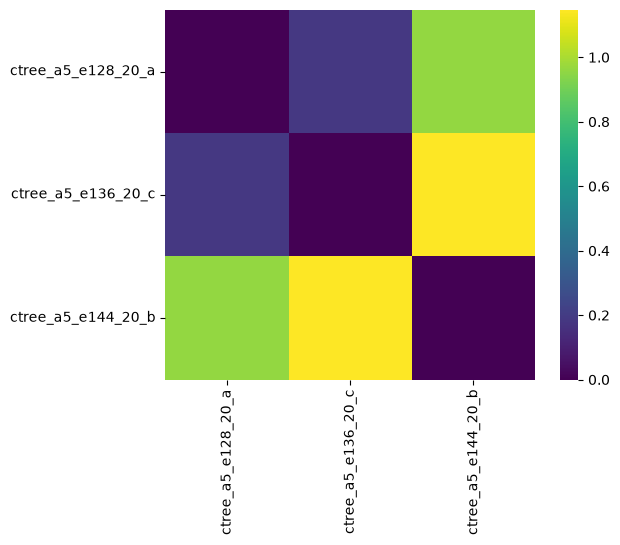

In [37]:
import seaborn as sns

LAYER = "a5"
sns.heatmap(mat_cons[LAYER], xticklabels=ord_cons[LAYER], yticklabels=ord_cons[LAYER], square=True, cmap="viridis")

<Axes: >

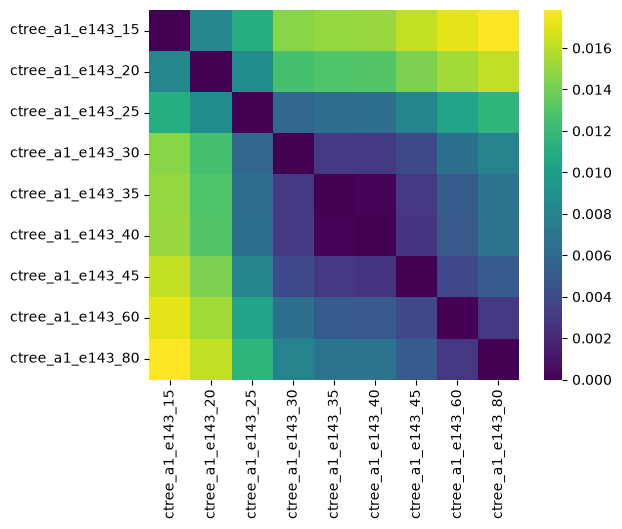

In [ ]:
LAYER = "a1"
sns.heatmap(mat_branch[LAYER], xticklabels=ord_branch[LAYER], yticklabels=ord_branch[LAYER], square=True, cmap="viridis")